# EDA: MTA ridership and congestion pricing

- GTP 7-13-2026
- Goal: explore Panel A before causal estimates (DiD / event study / synth)
- Primary data: `data/processed/panel_station_week.parquet`


## Checklist

**Minimal set (do these first)**
1. Systemwide weekly entries + policy event lines
2. Mean weekly entries by zone (`crz` / `border` / `control`)
3. Pre-period parallel trends (zones, pre window only)
4. Weekday-peak vs weekend by zone
5. Distance-to-boundary gradient (pre vs post change)
6. Station map by zone + CRZ polygon

**Identification / threats**
7. Indexed series (relative to 2024 pre-pause average)
8. Washout shaded; anticipation before T0
9. Post split at 2026-01-04 fare bundle
10. Raw zone-minus-control by month relative to T0

**Heterogeneity**
11. Borough facets
12. Top/bottom stations by pre→post % change

**Data quality**
13. Station-week coverage / missingness
14. Outcome distributions (log weekly entries)
15. Weather vs ridership scatter

Policy dates from `config/treatment.yaml` / analysis plan:
- pause announcement ~ `2024-06-05`
- T0 tolling `2025-01-05`
- fare bundle `2026-01-04`
- washout `2024-06-03` → `2025-01-04`


In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import geopandas as gpd
import contextily as cx
import yaml
from pathlib import Path

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (12, 4.5)
pd.set_option("display.max_columns", None)

ROOT = Path("..").resolve()
with open(ROOT / "config" / "treatment.yaml") as f:
    TREATMENT = yaml.safe_load(f)

T0 = pd.Timestamp(TREATMENT["treatment"]["t0"])
FARE = pd.Timestamp(TREATMENT["treatment"]["fare_change_date"])
PAUSE = pd.Timestamp("2024-06-05")
WASHOUT = (
    pd.Timestamp(TREATMENT["sample_windows"]["washout_start"]),
    pd.Timestamp(TREATMENT["sample_windows"]["washout_end"]),
)
PRE_END = pd.Timestamp(TREATMENT["sample_windows"]["pre_end"])

ZONE_COLORS = {
    "crz": "#c0392b",
    "border": "#e67e22",
    "control": "#2980b9",
    "near": "#7f8c8d",
}

def add_policy_lines(ax, *, shade_washout=True):
    if shade_washout:
        ax.axvspan(WASHOUT[0], WASHOUT[1], color="0.85", alpha=0.5, label="washout", zorder=0)
    for x, label, ls in [
        (PAUSE, "pause", ":"),
        (T0, "T0", "--"),
        (FARE, "fare bundle", "-."),
    ]:
        ax.axvline(x, color="black", lw=1.2, ls=ls, label=label, zorder=3)
    return ax


In [30]:
panel = pd.read_parquet(ROOT / "data" / "processed" / "panel_station_week.parquet")
panel["week_start"] = pd.to_datetime(panel["week_start"])

# Primary DiD comparison pool excludes `near`
panel_main = panel[panel["zone"].isin(["crz", "border", "control"])].copy()

print(panel.shape)
print(panel["zone"].value_counts())
print(panel["week_start"].min().date(), "→", panel["week_start"].max().date())
panel.head()


(100020, 28)
zone
control    80139
crz        15444
border      3276
near        1161
Name: count, dtype: int64
2022-01-03 → 2026-06-22


,station_complex_id,week_start,weekly_entries,weekday_peak_entries,weekend_entries,station_complex,borough,latitude,longitude,zone,in_crz,dist_to_crz_boundary_km,abs_dist_to_crz_boundary_km,precip_mm,tavg_c,log_weekly_entries,log_weekday_peak_entries,log_weekend_entries,iso_year,iso_week,holiday_week,fare_change,period,post,weeks_since_t0,exclude_reason,excluded,primary_sample
0,1,2022-01-03,42570.0,17171.0,8019.0,"Astoria-Ditmars Blvd (N,W)",Queens,40.775036,-73.91203,control,False,4.309936,4.309936,18.0,-0.164286,10.658929,9.751035,8.989694,2022,1,False,False,pre,False,-156,,False,True
1,1,2022-01-10,45376.0,19329.0,7710.0,"Astoria-Ditmars Blvd (N,W)",Queens,40.775036,-73.91203,control,False,4.309936,4.309936,9.4,-2.357143,10.722761,9.869414,8.950403,2022,2,False,False,pre,False,-155,,False,True
2,1,2022-01-17,46012.0,18711.0,8696.0,"Astoria-Ditmars Blvd (N,W)",Queens,40.775036,-73.91203,control,False,4.309936,4.309936,37.6,-0.785714,10.736679,9.836920,9.070733,2022,3,True,False,pre,False,-154,,False,True
3,1,2022-01-24,48215.0,21433.0,6811.0,"Astoria-Ditmars Blvd (N,W)",Queens,40.775036,-73.91203,control,False,4.309936,4.309936,22.9,-3.057143,10.783446,9.972734,8.826441,2022,4,False,False,pre,False,-153,,False,True
4,1,2022-01-31,53075.0,22761.0,9581.0,"Astoria-Ditmars Blvd (N,W)",Queens,40.775036,-73.91203,control,False,4.309936,4.309936,29.0,0.535714,10.879480,10.032848,9.167642,2022,5,False,False,pre,False,-152,,False,True


## 6. Zone map + CRZ polygon

/var/folders/yr/_034yfq96nzf7gbpshqqr7rc0000gn/T/ipykernel_87964/3536936417.py:22: UserWarning: Legend does not support handles for PatchCollection instances.
See: https://matplotlib.org/stable/tutorials/intermediate/legend_guide.html#implementing-a-custom-legend-handler
  ax.legend(loc="upper left", frameon=True)


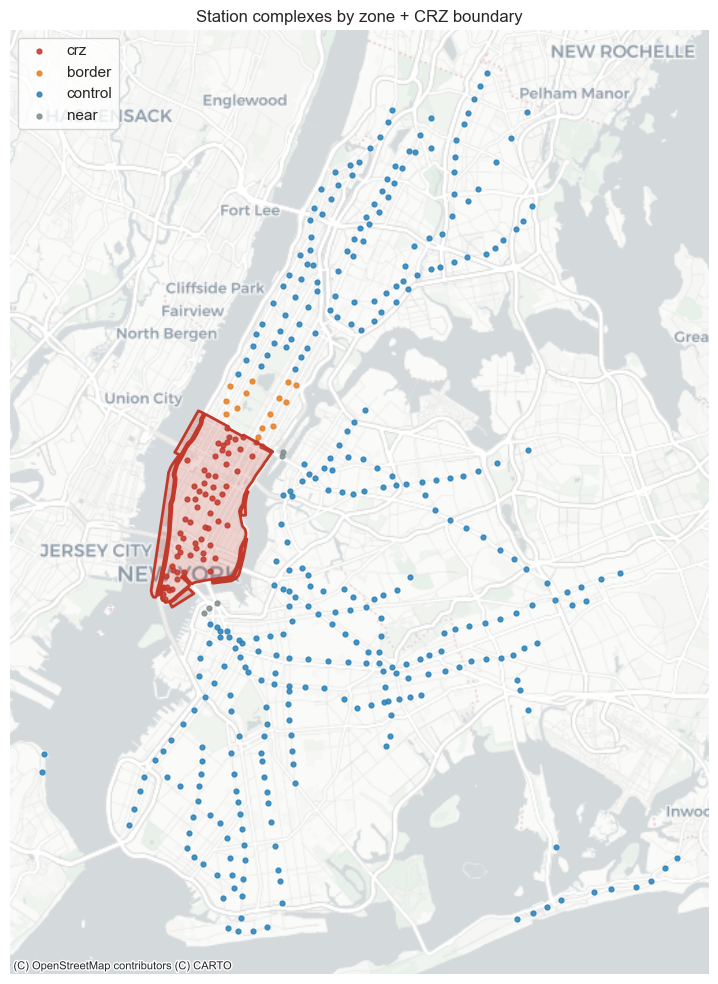

In [31]:
stations = (
    panel.drop_duplicates("station_complex_id")[
        ["station_complex_id", "station_complex", "zone", "longitude", "latitude"]
    ]
)
g_stations = gpd.GeoDataFrame(
    stations,
    geometry=gpd.points_from_xy(stations["longitude"], stations["latitude"]),
    crs="EPSG:4326",
).to_crs(epsg=3857)
crz = gpd.read_file(ROOT / "data" / "raw" / "crz" / "crz_boundary.geojson").to_crs(epsg=3857)

fig, ax = plt.subplots(figsize=(8, 10))
crz.plot(ax=ax, facecolor="#c0392b33", edgecolor="#c0392b", linewidth=2, label="CRZ")
for zone, color in ZONE_COLORS.items():
    sub = g_stations[g_stations["zone"] == zone]
    if len(sub):
        sub.plot(ax=ax, color=color, markersize=12, alpha=0.85, label=zone)
cx.add_basemap(ax, source=cx.providers.CartoDB.Positron)
ax.set_axis_off()
ax.set_title("Station complexes by zone + CRZ boundary")
ax.legend(loc="upper left", frameon=True)
plt.tight_layout()
plt.show()


## 1. Systemwide weekly entries + events

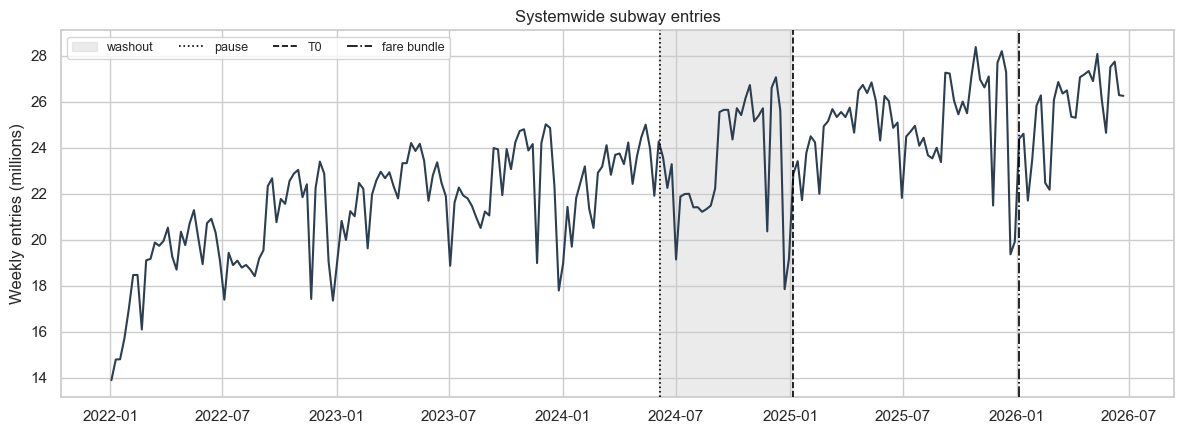

In [32]:
sys = (
    panel.groupby("week_start", as_index=False)["weekly_entries"]
    .sum()
    .sort_values("week_start")
)

fig, ax = plt.subplots()
ax.plot(sys["week_start"], sys["weekly_entries"] / 1e6, color="#2c3e50", lw=1.5)
add_policy_lines(ax)
ax.set_ylabel("Weekly entries (millions)")
ax.set_title("Systemwide subway entries")
ax.legend(loc="upper left", ncol=4, fontsize=9)
plt.tight_layout()
plt.show()


## 2–3. By zone (full sample) and pre-period parallel trends

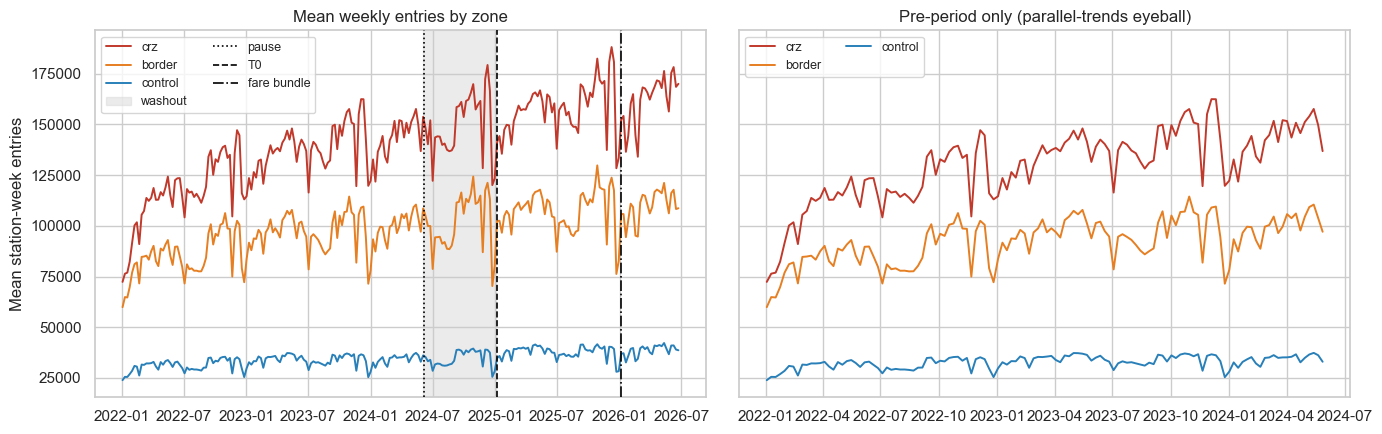

In [33]:
zone_week = (
    panel_main.groupby(["week_start", "zone"], as_index=False)["weekly_entries"]
    .mean()
    .sort_values("week_start")
)

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5), sharey=True)

for zone, color in ZONE_COLORS.items():
    if zone == "near":
        continue
    s = zone_week[zone_week["zone"] == zone]
    axes[0].plot(s["week_start"], s["weekly_entries"], color=color, lw=1.4, label=zone)
add_policy_lines(axes[0])
axes[0].set_title("Mean weekly entries by zone")
axes[0].set_ylabel("Mean station-week entries")
axes[0].legend(loc="upper left", ncol=2, fontsize=9)

pre = zone_week[zone_week["week_start"] <= PRE_END]
for zone, color in ZONE_COLORS.items():
    if zone == "near":
        continue
    s = pre[pre["zone"] == zone]
    axes[1].plot(s["week_start"], s["weekly_entries"], color=color, lw=1.4, label=zone)
axes[1].set_title("Pre-period only (parallel-trends eyeball)")
axes[1].legend(loc="upper left", ncol=2, fontsize=9)

plt.tight_layout()
plt.show()


## 7. Indexed to 2024 pre-pause average

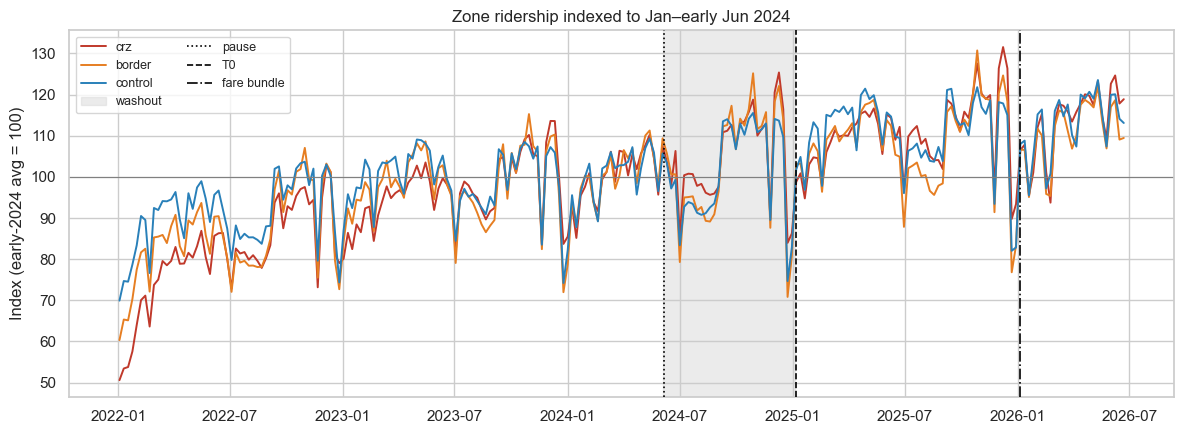

In [34]:
base = (
    panel_main[
        (panel_main["week_start"] >= "2024-01-01")
        & (panel_main["week_start"] < PAUSE)
    ]
    .groupby("zone")["weekly_entries"]
    .mean()
)

idx = zone_week.copy()
idx["index_2024"] = idx.apply(
    lambda r: 100 * r["weekly_entries"] / base.loc[r["zone"]], axis=1
)

fig, ax = plt.subplots()
for zone, color in ZONE_COLORS.items():
    if zone == "near":
        continue
    s = idx[idx["zone"] == zone]
    ax.plot(s["week_start"], s["index_2024"], color=color, lw=1.4, label=zone)
add_policy_lines(ax)
ax.axhline(100, color="0.5", lw=0.8)
ax.set_ylabel("Index (early-2024 avg = 100)")
ax.set_title("Zone ridership indexed to Jan–early Jun 2024")
ax.legend(loc="upper left", ncol=2, fontsize=9)
plt.tight_layout()
plt.show()


## 4. Weekday-peak vs weekend by zone

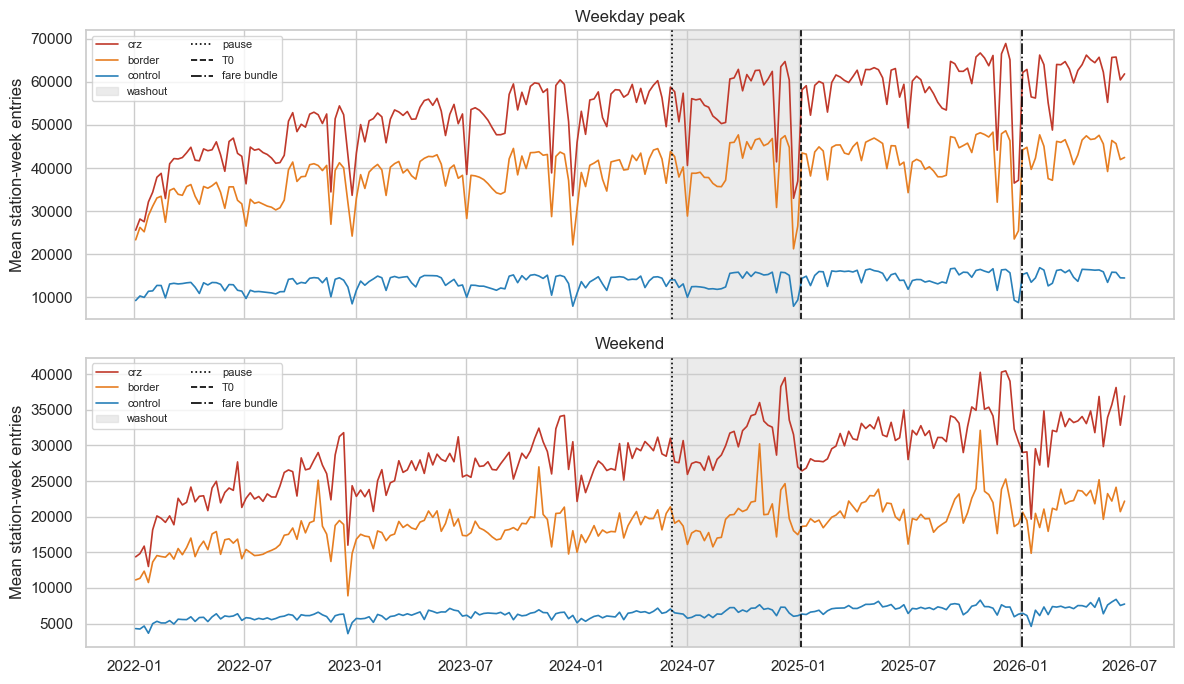

In [35]:
comp = (
    panel_main.groupby(["week_start", "zone"], as_index=False)
    .agg(
        weekday_peak_entries=("weekday_peak_entries", "mean"),
        weekend_entries=("weekend_entries", "mean"),
    )
)

fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True)
for ax, col, title in [
    (axes[0], "weekday_peak_entries", "Weekday peak"),
    (axes[1], "weekend_entries", "Weekend"),
]:
    for zone, color in ZONE_COLORS.items():
        if zone == "near":
            continue
        s = comp[comp["zone"] == zone]
        ax.plot(s["week_start"], s[col], color=color, lw=1.2, label=zone)
    add_policy_lines(ax)
    ax.set_title(title)
    ax.set_ylabel("Mean station-week entries")
    ax.legend(loc="upper left", ncol=2, fontsize=8)
plt.tight_layout()
plt.show()


## 5. Distance-to-boundary gradient (pre vs post change)

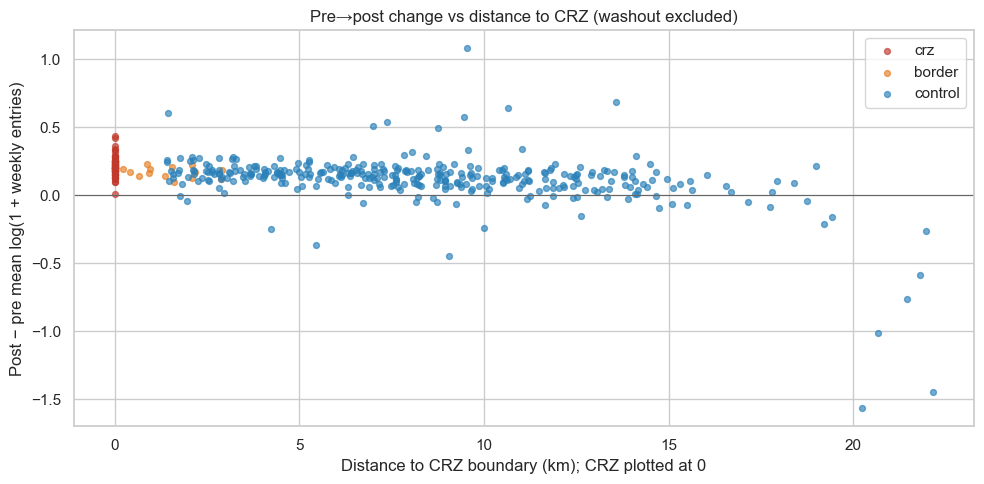

In [36]:
# Station-level mean log entries in pre vs post (exclude washout)
st = panel_main[panel_main["period"].isin(["pre", "post"])].copy()
agg = (
    st.groupby(["station_complex_id", "zone", "abs_dist_to_crz_boundary_km", "period"], as_index=False)[
        "log_weekly_entries"
    ]
    .mean()
    .pivot_table(
        index=["station_complex_id", "zone", "abs_dist_to_crz_boundary_km"],
        columns="period",
        values="log_weekly_entries",
    )
    .dropna()
    .reset_index()
)
agg["delta_log"] = agg["post"] - agg["pre"]

# For CRZ, signed distance is <=0; use 0 for "inside" on the x-axis gradient plot
agg["dist_plot"] = np.where(
    agg["zone"] == "crz", 0.0, agg["abs_dist_to_crz_boundary_km"]
)

fig, ax = plt.subplots(figsize=(10, 5))
for zone, color in ZONE_COLORS.items():
    if zone == "near":
        continue
    s = agg[agg["zone"] == zone]
    ax.scatter(s["dist_plot"], s["delta_log"], s=18, alpha=0.65, color=color, label=zone)
ax.axhline(0, color="0.4", lw=0.8)
ax.set_xlabel("Distance to CRZ boundary (km); CRZ plotted at 0")
ax.set_ylabel("Post − pre mean log(1 + weekly entries)")
ax.set_title("Pre→post change vs distance to CRZ (washout excluded)")
ax.legend()
plt.tight_layout()
plt.show()


## 10. Raw zone-minus-control by month relative to T0

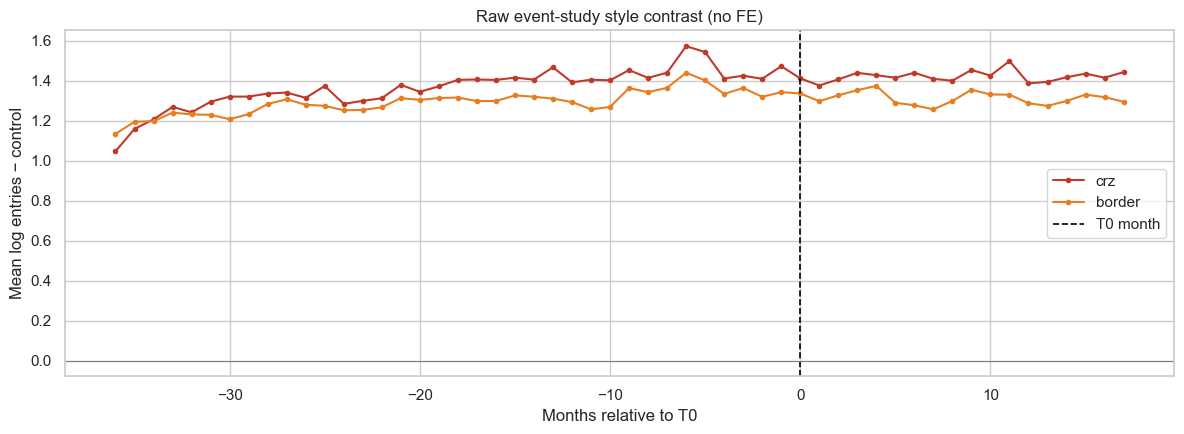

In [37]:
tmp = panel_main.copy()
tmp["month"] = tmp["week_start"].dt.to_period("M").dt.to_timestamp()
tmp["rel_month"] = (
    (tmp["month"].dt.year - T0.year) * 12 + (tmp["month"].dt.month - T0.month)
)

monthly = (
    tmp.groupby(["rel_month", "zone"], as_index=False)["log_weekly_entries"].mean()
)
ctrl = monthly[monthly["zone"] == "control"][["rel_month", "log_weekly_entries"]].rename(
    columns={"log_weekly_entries": "ctrl"}
)
diff = monthly[monthly["zone"].isin(["crz", "border"])].merge(ctrl, on="rel_month")
diff["vs_control"] = diff["log_weekly_entries"] - diff["ctrl"]

fig, ax = plt.subplots()
for zone, color in [("crz", ZONE_COLORS["crz"]), ("border", ZONE_COLORS["border"])]:
    s = diff[diff["zone"] == zone].sort_values("rel_month")
    ax.plot(s["rel_month"], s["vs_control"], marker="o", ms=3, color=color, label=zone)
ax.axvline(0, color="black", ls="--", lw=1.2, label="T0 month")
ax.axhline(0, color="0.5", lw=0.8)
ax.set_xlabel("Months relative to T0")
ax.set_ylabel("Mean log entries − control")
ax.set_title("Raw event-study style contrast (no FE)")
ax.legend()
plt.tight_layout()
plt.show()


## 13–14. Coverage and outcome distribution

weeks in panel: 234
count    428.000000
mean     233.691589
std        1.981938
min      217.000000
25%      234.000000
50%      234.000000
75%      234.000000
max      234.000000
Name: n_weeks, dtype: float64


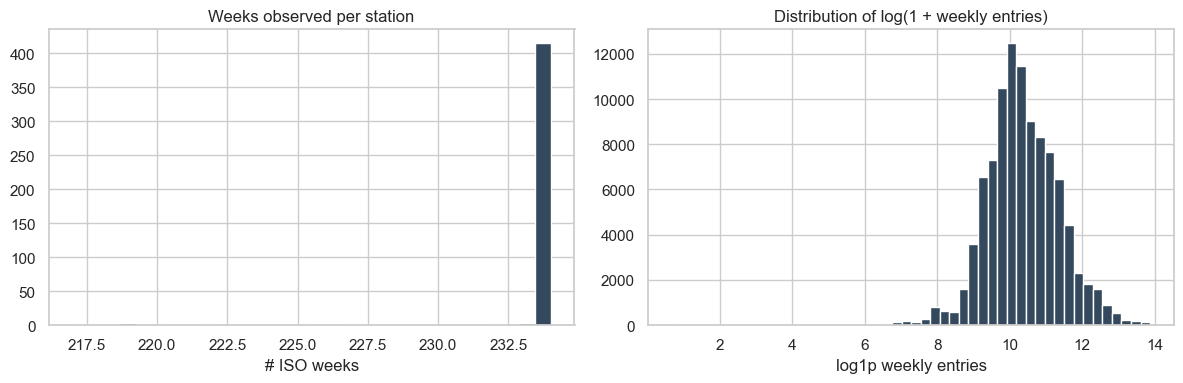

In [38]:
coverage = (
    panel.groupby("station_complex_id")["week_start"].nunique()
    .rename("n_weeks")
    .reset_index()
)
print("weeks in panel:", panel["week_start"].nunique())
print(coverage["n_weeks"].describe())

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(coverage["n_weeks"], bins=30, color="#34495e", edgecolor="white")
axes[0].set_title("Weeks observed per station")
axes[0].set_xlabel("# ISO weeks")

axes[1].hist(panel["log_weekly_entries"], bins=50, color="#34495e", edgecolor="white")
axes[1].set_title("Distribution of log(1 + weekly entries)")
axes[1].set_xlabel("log1p weekly entries")
plt.tight_layout()
plt.show()


## 15. Weather vs ridership

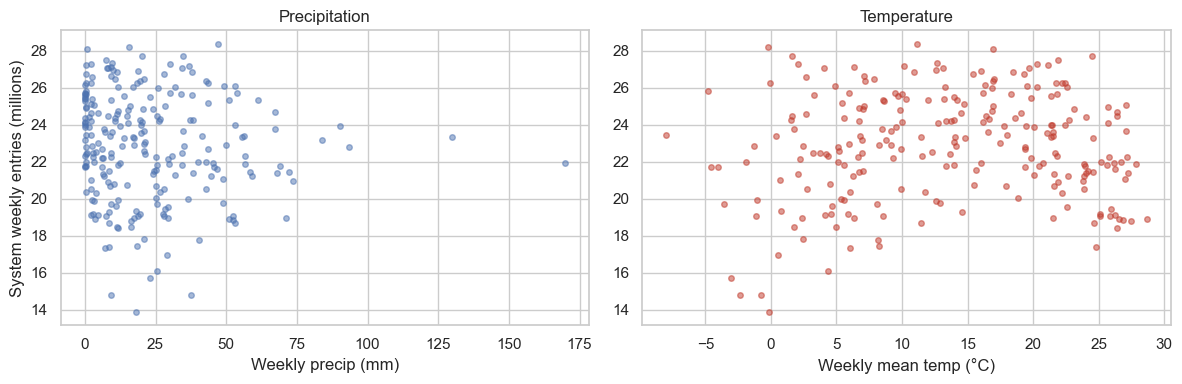

In [39]:
w = (
    panel.groupby("week_start", as_index=False)
    .agg(
        weekly_entries=("weekly_entries", "sum"),
        precip_mm=("precip_mm", "first"),
        tavg_c=("tavg_c", "first"),
    )
)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].scatter(w["precip_mm"], w["weekly_entries"] / 1e6, alpha=0.5, s=16)
axes[0].set_xlabel("Weekly precip (mm)")
axes[0].set_ylabel("System weekly entries (millions)")
axes[0].set_title("Precipitation")

axes[1].scatter(w["tavg_c"], w["weekly_entries"] / 1e6, alpha=0.5, s=16, color="#c0392b")
axes[1].set_xlabel("Weekly mean temp (°C)")
axes[1].set_title("Temperature")
plt.tight_layout()
plt.show()


## 12. Top / bottom stations by pre→post % change

Washout excluded. `% change = 100 * (post_mean / pre_mean - 1)` on weekly entries.
Colored by zone.



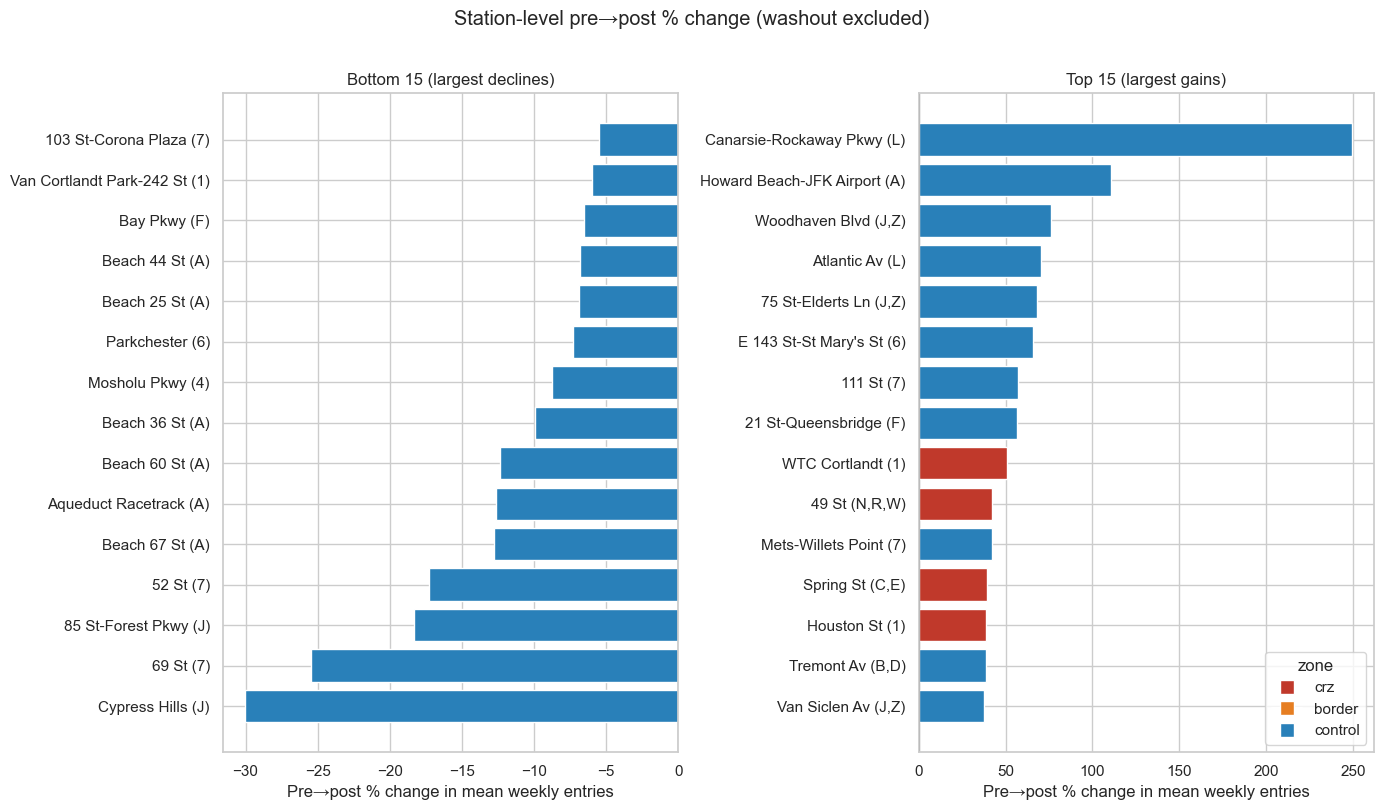

Bottom stations:


period,station_complex,zone,borough,pre,post,pct_change
408,Cypress Hills (J),control,Brooklyn,5678.7,3971.6,-30.1
320,69 St (7),control,Queens,25533.4,19027.3,-25.5
406,85 St-Forest Pkwy (J),control,Queens,15217.6,12427.9,-18.3
322,52 St (7),control,Queens,26305.6,21753.4,-17.3
87,Beach 67 St (A),control,Queens,8815.4,7687.7,-12.8
77,Aqueduct Racetrack (A),control,Queens,3870.5,3380.7,-12.7
88,Beach 60 St (A),control,Queens,6744.3,5912.8,-12.3
90,Beach 36 St (A),control,Queens,3318.4,2989.8,-9.9
249,Mosholu Pkwy (4),control,Bronx,31930.3,29138.4,-8.7
235,Parkchester (6),control,Bronx,59254.4,54925.3,-7.3


Top stations:


period,station_complex,zone,borough,pre,post,pct_change
30,Canarsie-Rockaway Pkwy (L),control,Brooklyn,14098.4,49294.4,249.6
79,Howard Beach-JFK Airport (A),control,Queens,12637.0,26590.5,110.4
405,"Woodhaven Blvd (J,Z)",control,Queens,12205.2,21496.6,76.1
25,Atlantic Av (L),control,Brooklyn,6844.4,11675.2,70.6
407,"75 St-Elderts Ln (J,Z)",control,Queens,9238.1,15514.3,67.9
244,E 143 St-St Mary's St (6),control,Bronx,4936.7,8195.2,66.0
314,111 St (7),control,Queens,43668.6,68702.6,57.3
104,21 St-Queensbridge (F),control,Queens,33487.3,52395.9,56.5
200,WTC Cortlandt (1),crz,Manhattan,56888.8,85753.3,50.7
1,"49 St (N,R,W)",crz,Manhattan,101199.8,143755.0,42.1


In [40]:
st = panel_main[panel_main["period"].isin(["pre", "post"])].copy()
chg = (
    st.groupby(["station_complex_id", "station_complex", "zone", "borough", "period"], as_index=False)[
        "weekly_entries"
    ]
    .mean()
    .pivot_table(
        index=["station_complex_id", "station_complex", "zone", "borough"],
        columns="period",
        values="weekly_entries",
    )
    .dropna()
    .reset_index()
)
chg["pct_change"] = 100 * (chg["post"] / chg["pre"] - 1)

n = 15
top = chg.nlargest(n, "pct_change").assign(rank_side="largest gains")
bottom = chg.nsmallest(n, "pct_change").assign(rank_side="largest declines")
rank = pd.concat([bottom, top], ignore_index=True)
rank = rank.sort_values(["rank_side", "pct_change"])

fig, axes = plt.subplots(1, 2, figsize=(14, 8), sharex=False)
for ax, side, title in [
    (axes[0], "largest declines", f"Bottom {n} (largest declines)"),
    (axes[1], "largest gains", f"Top {n} (largest gains)"),
]:
    s = rank[rank["rank_side"] == side]
    colors = s["zone"].map(ZONE_COLORS)
    ax.barh(s["station_complex"], s["pct_change"], color=colors)
    ax.axvline(0, color="0.3", lw=0.8)
    ax.set_title(title)
    ax.set_xlabel("Pre→post % change in mean weekly entries")

handles = [
    plt.Line2D([0], [0], marker="s", color="w", markerfacecolor=c, markersize=10, label=z)
    for z, c in ZONE_COLORS.items()
    if z != "near"
]
axes[1].legend(handles=handles, title="zone", loc="lower right")
fig.suptitle("Station-level pre→post % change (washout excluded)", y=1.01)
plt.tight_layout()
plt.show()

display_cols = ["station_complex", "zone", "borough", "pre", "post", "pct_change"]
print("Bottom stations:")
display(bottom.sort_values("pct_change")[display_cols].round(1))
print("Top stations:")
display(top.sort_values("pct_change", ascending=False)[display_cols].round(1))


## Optional follow-ups

- Facet zone plots by borough
- Re-run weekday/weekend split for `crz` vs `control` only
- Check `near` stations separately (Brooklyn Bridge approaches, Roosevelt Island)
